
# 3.3 Three-Dimensional (3D) Random Walk

#### Definition
The walker moves in 3D space. At each step, it moves in one of six axis-aligned directions:

$$\text{Direction} \in \{\ +X,\ -X,\ +Y,\ -Y,\ +Z,\ -Z\ \}, \quad \text{each with prob.} = \frac{1}{6}$$

#### Position Update Rule

$$x_n = x_{n-1} + \Delta x, \quad y_n = y_{n-1} + \Delta y, \quad z_n = z_{n-1} + \Delta z$$

#### Distance from Origin

$$r_n = \sqrt{x_n^2 + y_n^2 + z_n^2}$$

#### Properties
| Property | Value |
|---|---|
| Directions | 6 (±X, ±Y, ±Z) |
| Space | X-Y-Z |
| RMS distance | $\sqrt{N}$ |
| Returns to origin? | No (probability ≈ 0.3405 only) |

> **Pólya's Theorem (3D):** In 3D, a random walk returns to the origin with probability only
> **≈ 34%**. In higher dimensions, walkers almost surely never return.

---

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

In [22]:
rng = np.random.default_rng(seed= 12345)
def random_walk_3D(no_of_steps):
    dx = np.zeros( no_of_steps)
    dy = np.zeros(no_of_steps)
    dz = np.zeros( no_of_steps)

    direction = rng.integers(0, 6 , size = no_of_steps)

    dx[direction == 0] = 1
    dx[direction == 1] = -1
    dy[direction == 2] = 1
    dy[direction == 3] = -1
    dz[direction == 4] = 1
    dz[direction == 5] = -1

    walk_x = np.concatenate([[0], np.cumsum(dx)])
    walk_y = np.concatenate([[0], np.cumsum(dy)])
    walk_z = np.concatenate([[0], np.cumsum(dz)])




    return (int(walk_x[-1]), int(walk_y[-1]) , int(walk_z[-1])), walk_x, walk_y ,walk_z


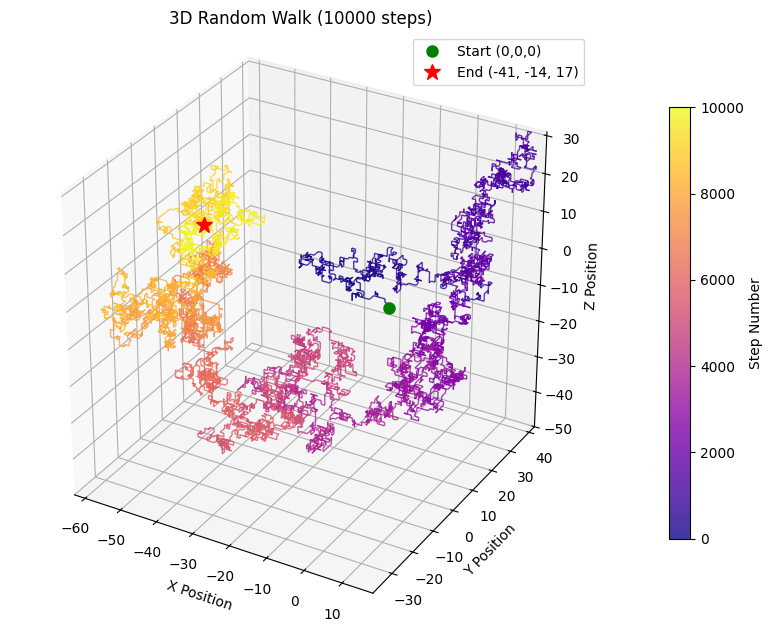

In [23]:
no_of_steps = 10000
(final_pos), walk_x, walk_y, walk_z = random_walk_3D(no_of_steps)

# 2. Setup the 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Create Gradient color to show progression of the walk
# Reshape points to 3 dimensions instead of 2
points = np.array([walk_x, walk_y, walk_z]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm_color = plt.Normalize(0, len(walk_x))
# Use Line3DCollection instead of LineCollection
lc = Line3DCollection(segments, cmap='plasma', norm=norm_color, linewidth=1.0, alpha=0.8)
lc.set_array(np.arange(len(walk_x)))
ax.add_collection3d(lc)

# 4. Start and end markers (passing them as lists inside the plot function)
ax.plot([walk_x[0]], [walk_y[0]], [walk_z[0]], 'go', markersize=8, label='Start (0,0,0)', zorder=5)
ax.plot([walk_x[-1]], [walk_y[-1]], [walk_z[-1]], 'r*', markersize=12, label=f'End {final_pos}', zorder=5)

# 5. Setting limits is required for add_collection3d as it doesn't auto-scale
ax.set_xlim(min(walk_x), max(walk_x))
ax.set_ylim(min(walk_y), max(walk_y))
ax.set_zlim(min(walk_z), max(walk_z))

# 6. Keep the aspect ratio 'equal' in 3D
x_range = abs(ax.get_xlim3d()[1] - ax.get_xlim3d()[0])
y_range = abs(ax.get_ylim3d()[1] - ax.get_ylim3d()[0])
z_range = abs(ax.get_zlim3d()[1] - ax.get_zlim3d()[0])
ax.set_box_aspect((x_range, y_range, z_range))

# 7. Labels, Colorbar and details
cbar = fig.colorbar(lc, ax=ax, label='Step Number', shrink=0.7, pad=0.1)
ax.set_title(f'3D Random Walk ({no_of_steps} steps)')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.legend()

plt.show()

In [25]:
# total distanc traveled 
distance = np.sqrt(np.array(walk_x) **2 + np.array(walk_y) **2 +np.array(walk_z)**2)
print(distance)
steps_nums = len(distance)
print(f"Final Distance from Origin: {distance[-1]:.2f}")
print(f"Theoretical Expected (√N):  {np.sqrt(no_of_steps):.2f}")

[ 0.          1.          1.41421356 ... 47.72839826 47.42362281
 46.54030511]
Final Distance from Origin: 46.54
Theoretical Expected (√N):  100.00


* There is only 34% probability that random walk comes at its origin distance.